# Overview

This notebook contains functionality for percent accuracy histogram analysis. This includes:

- comparison for two percent accuracy histograms.
- creating visual plots for histogram peaks (that occurr in the 0 and 1 bins) that are saved to a file
- plotting histograms to analyze frequency of voxel numbers (1 to 27) that occur in the histogram peaks. 
- creating a confusion matrix to analyze frequency of voxel positions in the original and predicted data. 

In [55]:
from sklearn.metrics import confusion_matrix, classification_report
from pointnet_model import pnet
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
import os

#set batch size
BATCH_SIZE = 32

#set num_points
num_points = 512

#set num_classes
# num_classes = 27
num_classes = 24

# Comparing Two Percent Accuracy Histograms

In [69]:
#specify models: 
#M1:
model1_file_stem = 'models/2024-04-17-19:52:36/weights/cp-090.ckpt' 
data1_file_stem = 'voxel_data/Mg22_size512'

#M2
model2_file_stem = 'models/2024-04-17-19:52:36/weights/cp-091.ckpt' 
data2_file_stem = 'voxel_data/Mg22_size512'

## Create Percent Accuracy array for Model 1

In [70]:
# build model
model1 = pnet(sem_seg_flag=True, num_points=num_points, num_classes=num_classes)
model1.load_weights(model1_file_stem)

 # load test data for model1
test_ds = np.load('{}{}'.format(data1_file_stem, 'test.npy'))
test_features = tf.data.Dataset.from_tensor_slices(test_ds[:, :, :3]).batch(BATCH_SIZE)
test_labels = test_ds[:, :, 3]

# make predictions for model1
predicted_probabilities = model1.predict(test_features)
predictions = np.argmax(predicted_probabilities, axis=2)

# set up name and time for model 1
model1_name = model1_file_stem.split("/")[-1] #modified to save model/ckpt name
model1_time =  model1_file_stem.split("/")[-3] #added to save timestamp
    
#create percent accuracy for m1 
percent_accuracy1 = np.mean(test_labels == predictions, axis=1) #along X axis
print(percent_accuracy1)

2024-04-19 09:24:45.703516: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype double and shape [1192,512,3]
	 [[{{node Placeholder/_0}}]]


38/38 [==============================] - 6s 144ms/step
[0.         0.85546875 0.86914062 ... 0.203125   0.25       0.09960938]


## Create Percent Accuracy array for Model 2

In [71]:
#build model
model2 = pnet(sem_seg_flag=True, num_points=num_points, num_classes=num_classes)
model2.load_weights(model2_file_stem)

# load test data for model2
test_ds2 = np.load('{}{}'.format(data2_file_stem, 'test.npy'))
test_features2 = tf.data.Dataset.from_tensor_slices(test_ds2[:, :, :3]).batch(BATCH_SIZE)
test_labels2 = test_ds2[:, :, 3]

# make predictions for model2
predicted_probabilities2 = model2.predict(test_features2)
predictions2 = np.argmax(predicted_probabilities2, axis=2)

# evaluate results for model 2
model2_name = model2_file_stem.split("/")[-1] #modified to save model/ckpt name
model2_time =  model2_file_stem.split("/")[-3] #added to save timestamp

# create percent accuracy for model 2 
percent_accuracy2 = np.mean(test_labels2 == predictions2, axis=1) #along X axis

2024-04-19 09:24:59.725559: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype double and shape [1192,512,3]
	 [[{{node Placeholder/_0}}]]


38/38 [==============================] - 6s 144ms/step


## Plot Overlaid Histograms

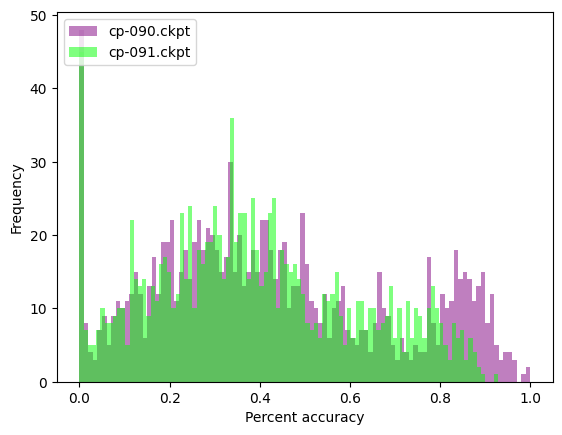

In [73]:
#set title
#title = model1_name + model1_time + " vs " + model2_name + model2_time

plt.figure()
plt.hist(percent_accuracy1, bins=100, alpha=0.5, color='purple', label=model1_name)
plt.hist(percent_accuracy2, bins=100, alpha=0.5, color='lime', label=model2_name)
plt.xlabel("Percent accuracy")
plt.ylabel("Frequency")
#plt.title(title)
plt.legend(loc = 'upper left')
plt.show()
#plt.savefig("plots/evaluations/comparison_{}.png".format(title)) #to save as png 

# Visualization Plots for Histogram Peaks

Creates and saves plots for events in each peak for analysis. Currently designed for peaks at 0 bin (relaxed to include 0% to 10% accuracy events) and 1 bin (relaxed to include 90% to 100% accuracy events). See code comments. 

Contains some infrastructure to analyze data within peaks (found under "for peak analysis" comments). 

### Helper Function to Plot Events

Copied from plotting.py, modified for peak analysis.

In [74]:
VOXEL_COLORS = np.array(['brown','salmon','coral','midnightblue','olive',
                         'greenyellow','forestgreen','aquamarine', 
                         'mediumturquoise','teal','darkolivegreen','saddlebrown',
                         'dodgerblue','darkorange', 'fuchsia','royalblue',
                         'deeppink','blueviolet','plum','slategray',
                         'deeppink','black','navy','mediumslateblue','tomato',
                         'orangered','green'])

def _plot_event(fig, panel, event_id, event, title, colors=None):
    """ Helper function to plot events. From plotting.py, but now counts colors used in plotting. """
    ax = fig.add_subplot(1, 4, panel, projection='3d')
    ax.axes.set_xlim3d(left=0, right=1)
    ax.axes.set_ylim3d(bottom=0, top=1)
    ax.axes.set_zlim3d(bottom=0, top=1)
    if colors is None:
        colors = VOXEL_COLORS[event[:,3].astype(int)]

    color_set = set(colors)
    num_colors = len(color_set)
  
    ax.scatter3D(event[:,0], event[:,2], event[:,1], color=colors, s=1)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('z [mm]')
    ax.set_zlabel('y [mm]')
    # plt.title('Event {} {}'.format(event_id, title))
    plt.title(title)
    
    return num_colors

### Setup and Initializing Variables

In [75]:
#specify file path and names
data_file_stem = 'voxel_data/Mg22_size512'
model_file_stem = 'models/2024-04-17-16:35:23/weights/cp-081.ckpt'
model_name = model_file_stem.split("/")[-3]
ckpt_name = model_file_stem.split("/")[-1]

# loading in data
original_ds = np.load('{}{}'.format(data_file_stem, '_voxelated.npy'))
shuffled_ds = np.load('{}{}'.format(data_file_stem, '_shuffled_voxels_only.npy'))
base_voxels = np.load('{}{}'.format(data_file_stem, '_base_voxels.npy'))

voxel_bounds = np.load('voxel_data/voxel_bounds.npy')
min_bounds = voxel_bounds[:, 0, :]

test_ds = np.load('{}{}'.format(data_file_stem, 'test.npy'))
test_features = tf.data.Dataset.from_tensor_slices(test_ds[:, :, :3]).batch(BATCH_SIZE)
test_event_nums = test_ds[:,:,5]

targets = test_ds[:, :, 3]    #targets = test_labels

model = pnet(sem_seg_flag=True, num_points=512, num_classes=27)
model.load_weights(model_file_stem)

# make predictions
predicted_probabilities = model.predict(test_features)
predictions = np.argmax(predicted_probabilities, axis=2)

#initializing variables
zero_bin = []
one_bin = []
colors_zero_bin = []
colors_one_bin = []

# uncomment when running on a checkpoint for the first time in this notebook/ plotting.py was not run before
# os.makedirs('plots/{}/{}/0_bin'.format(model_name, ckpt_name)) 
# os.makedirs('plots/{}/{}/1_bin'.format(model_name, ckpt_name))

2024-04-19 09:27:10.655723: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype double and shape [1192,512,3]
	 [[{{node Placeholder/_0}}]]


38/38 [==============================] - 6s 146ms/step


### Create and Save Plots
Saves in same folders where plotting.py saves results! This is essentially the same function, but with relaxed conditions on accuracy. If previous data is required, rename the folders and uncomment os.makedirs() commands in cell above. Otherwise, prior results will be replaced. 

In [76]:
for i in range(len(targets)):

    # finds the events from the zero bin
    # restrictions relaxed to include 0 uptil 0.10 bins, i.e 0 - 10% accuracy. 
    if np.mean(targets[i,:] == predictions[i]) >= 0.0 and np.mean(targets[i,:] == predictions[i]) <= 0.10:
        event_id = int(test_event_nums[i,0])          
        fig = plt.figure(figsize=(17,7.5))
        zero_bin.append(original_ds[event_id,:,:])

        # plot original events + shuffled events
        num_zcolors = _plot_event(fig, 1, event_id, original_ds[event_id,:,:], 'Original Event')
        num_zcolors2 = _plot_event(fig, 2, event_id, shuffled_ds[event_id,:,:], 'Shuffled Event')

        # plot predictions but with target colors (i.e., colored according to
        # the voxel of origin)
        translated_evt = base_voxels[event_id,:,:].copy()
        preds = predictions[i]
        translated_evt[:,:3] = translated_evt[:,:3] + min_bounds[preds] 
        num_zcolors3 =_plot_event(fig, 3, event_id, translated_evt, 'Reconstructed Event')

        # plot predictions with hit/miss colors (misses = red, hits = blue)
        MISS_HIT_COLORS = np.array(['red', 'blue'])
        colors = MISS_HIT_COLORS[(targets[i,:] == predictions[i,:]).astype(int)]
        temp_zero =_plot_event(fig, 4, event_id, translated_evt, 'Reconstruction Accuracy', colors=colors)

        #for peak analysis
        assert (num_zcolors == num_zcolors2 == num_zcolors3)
        colors_zero_bin.append(num_zcolors)
    
        plt.savefig('plots/{}/{}/0_bin/{}_voxels.png'.format(model_name, ckpt_name, event_id))
        plt.close() #to prevent jupyter displaying ~50 plots in the notebook outputs

    # finds the events from the one bin
    # restrictions relaxed to include 0.90 uptil 1.0 bins, i.e 90 - 100% accuracy. 
    elif np.mean(targets[i,:] == predictions[i])>= 0.90 and np.mean(targets[i,:] == predictions[i]) <= 1.0:    # 100% accuracy
        event_id = int(test_event_nums[i,0])          
        fig = plt.figure(figsize=(17,7.5))
        one_bin.append(original_ds[event_id,:,:])

        # plot original events + shuffled events
        num_ocolors = _plot_event(fig, 1, event_id, original_ds[event_id,:,:], 'Original Event')
        num_ocolors2 = _plot_event(fig, 2, event_id, shuffled_ds[event_id,:,:], 'Shuffled Event')

        # plot predictions but with target colors (i.e., colored according to
        # the voxel of origin)
        translated_evt = base_voxels[event_id,:,:].copy()
        preds = predictions[i]
        translated_evt[:,:3] = translated_evt[:,:3] + min_bounds[preds] 
        num_ocolors3 = _plot_event(fig, 3, event_id, translated_evt, 'Reconstructed Event')

        # plot predictions with hit/miss colors (misses = red, hits = blue)
        MISS_HIT_COLORS = np.array(['red', 'blue'])
        colors = MISS_HIT_COLORS[(targets[i,:] == predictions[i,:]).astype(int)]
        temp_one = _plot_event(fig, 4, event_id, translated_evt, 'Reconstruction Accuracy', colors=colors)

        #for peak analysis
        assert (num_ocolors == num_ocolors2 == num_ocolors3)
        colors_one_bin.append(num_ocolors)
        
        plt.savefig('plots/{}/{}/1_bin/{}_voxels.png'.format(model_name,ckpt_name,event_id))
        plt.close() #to prevent jupyter displaying ~50 plots in the notebook outputs

np.save('plots/{}/{}/0_bin/0_data'.format(model_name, ckpt_name), zero_bin)
np.save('plots/{}/{}/1_bin/1_data'.format(model_name, ckpt_name), one_bin)

# Analyzing Peaks

Creates 2 histograms of frequency vs. number of voxels for data in each peak. Requires running Visualization Plots functionality.

### Plot Frequency vs. Number of Voxels Histograms

<Figure size 640x480 with 0 Axes>

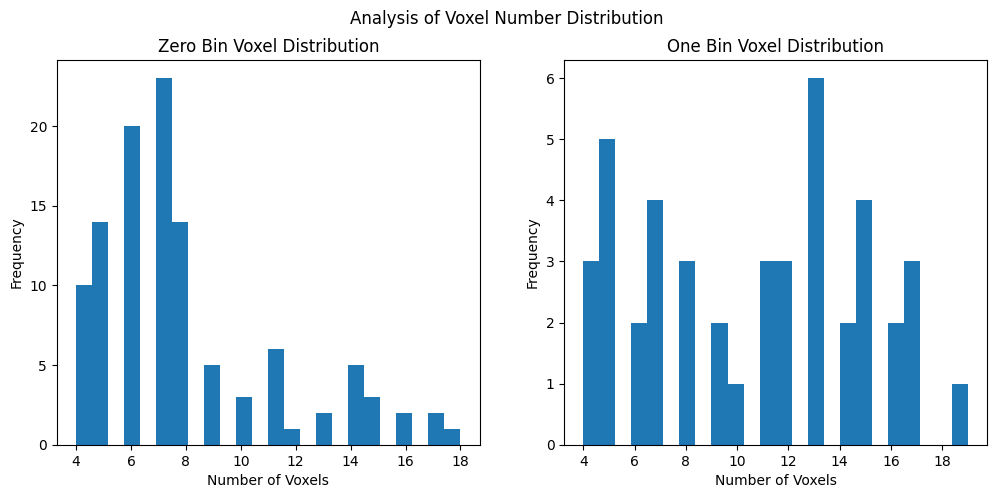

In [77]:
analysis_fig = plt.figure()
analysis_fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5)) 

#zero-bin
# ax1.hist(colors_zero_bin, bins=27) #only 27 voxel colors possible
ax1.hist(colors_zero_bin, bins=24) #only 27 voxel colors possible
ax1.set_title('Zero Bin Voxel Distribution')
ax1.set_xlabel('Number of Voxels')
ax1.set_ylabel('Frequency')

#one-bin
# ax2.hist(colors_one_bin, bins=27)
ax2.hist(colors_one_bin, bins=24)
ax2.set_title('One Bin Voxel Distribution')
ax2.set_xlabel('Number of Voxels')
ax2.set_ylabel('Frequency')

analysis_fig.suptitle('Analysis of Voxel Number Distribution')
analysis_fig.show()
#plt.savefig('plots/{}/{}/peak_analysis.png'.format(model_name,ckpt_name)) #uncomment to save in directory


### Plot Frequency vs. Voxel ID (/Position) Confusion Matrix

To observe where the voxels were originally positioned versus where the model places them during reconstruction. This helps analyze if the model does better with certain positions, such as voxel positions closer to the origin.

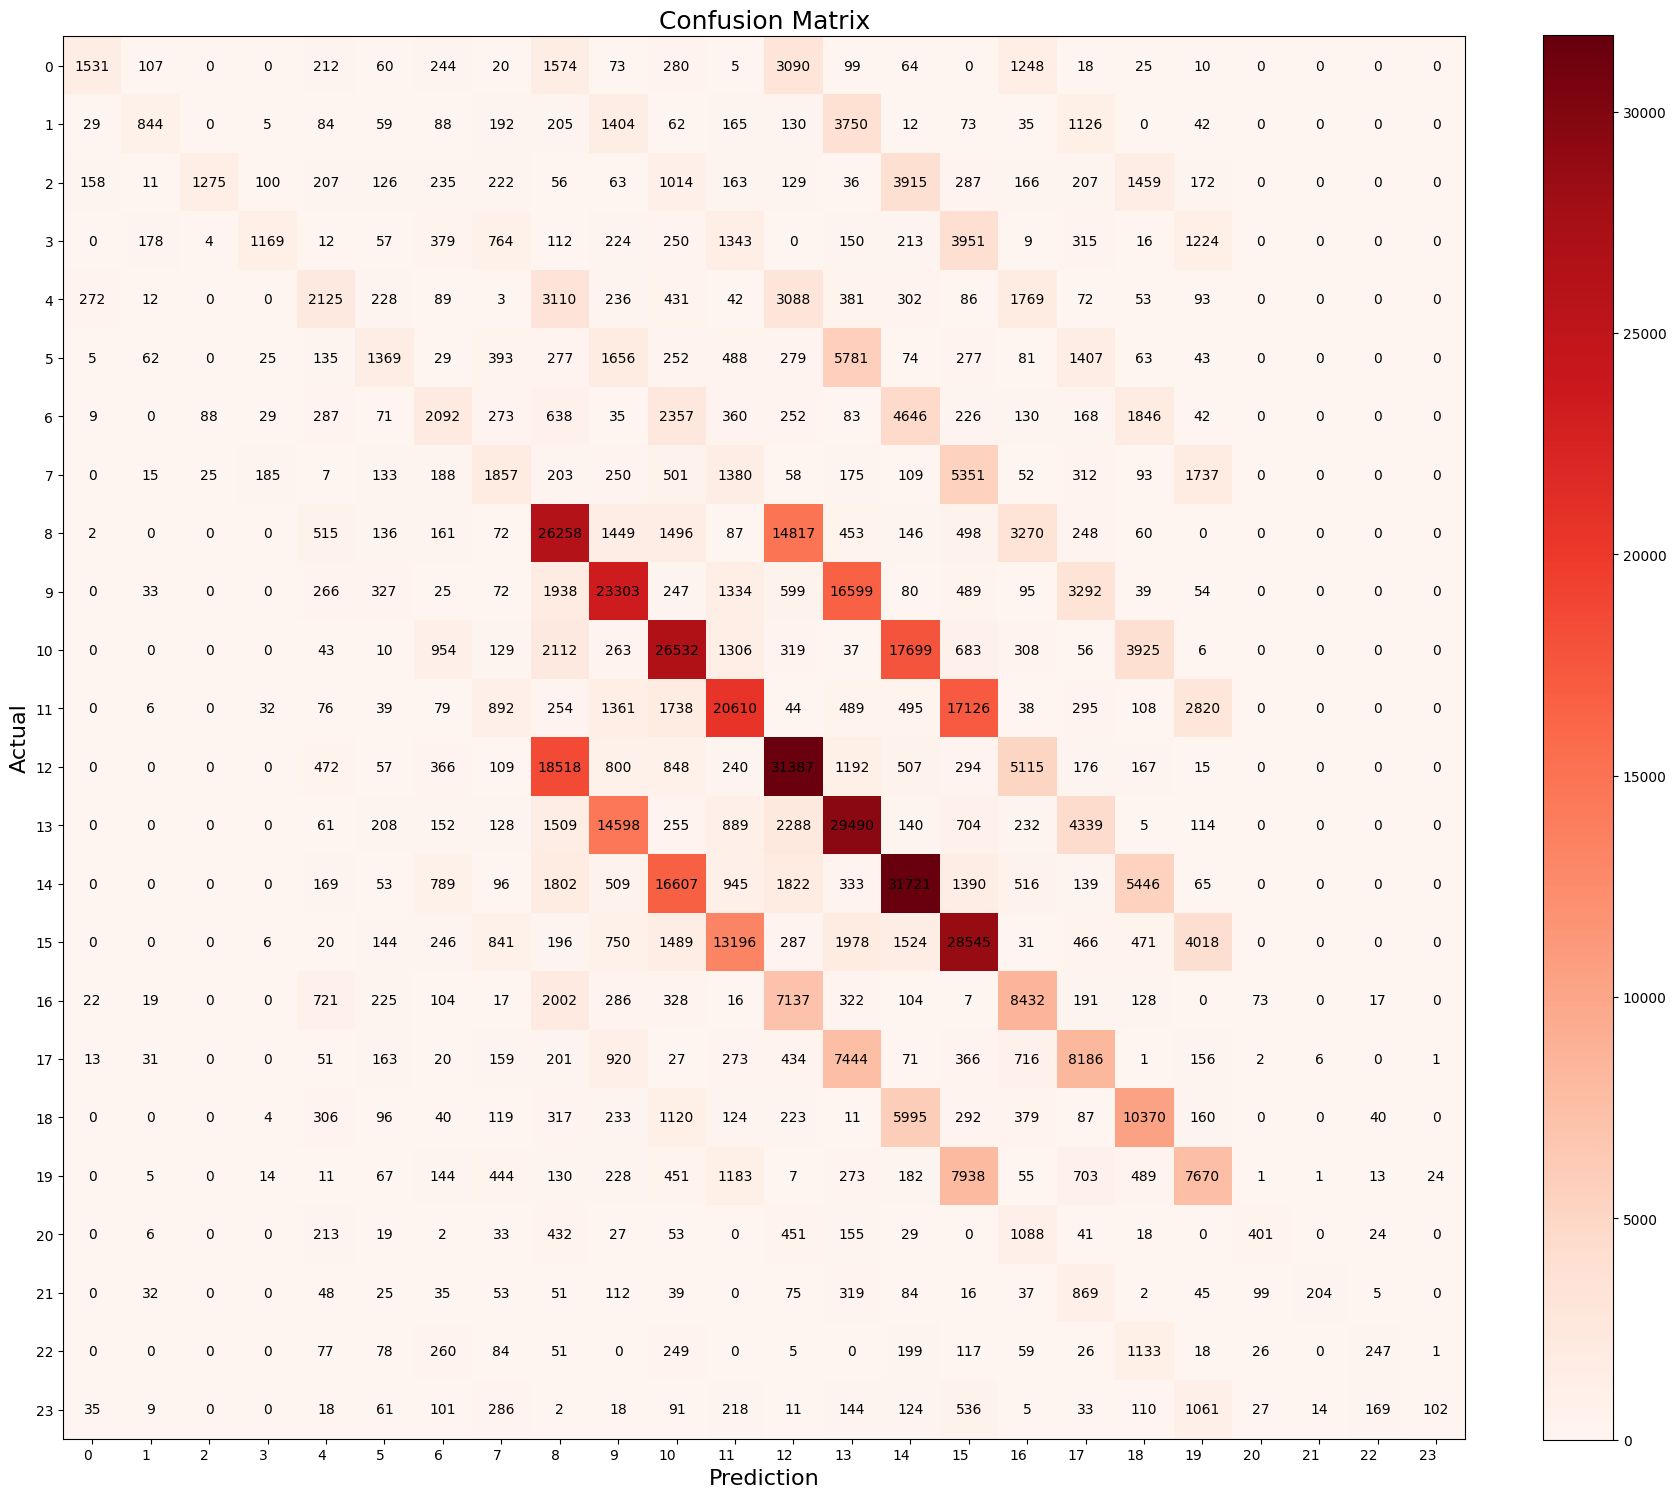

In [78]:
#original data voxel IDs in _voxelated.npy
#predicted data voxel IDs in  predictions

#2D -> 1D array #row-major order
targets1D = targets.flatten() 
predictions1D = predictions.flatten()

cm = confusion_matrix(targets1D, predictions1D)


fig, ax = plt.subplots(figsize=(20,20))
# sns.heatmap(cm,annot=True, cmap= 'Reds', fmt='g'); #seaborn heatmap

# plt.xlabel('Prediction',fontsize=16)
# plt.ylabel('Actual',fontsize=16)
# plt.title('Confusion Matrix',fontsize=18)
# plt.savefig("heatmap.png") #saves into TPCNet directory

# print(classification_report(targets1D, predictions1D))
#macro avg potentially influenced by "fake" zeroes in precision & F1 scores

# print out the actual data and plot its distribution to verify the confusion matrix
# print(targets1D)
# plt.figure(figsize = (12, 5))
# plt.hist(targets1D, bins=27)
# plt.show()

# if the heatmap function above doesn't work, try the following code
im = ax.imshow(cm, cmap = "Reds")
fig.colorbar(im, fraction = 0.0453)

plt.setp(ax.get_xticklabels(), ha="right",
         rotation_mode="anchor")

for i in range(len(cm[:,0])):
    for j in range(len(cm[0,:])):
        text = ax.text(j, i, cm[i, j],
                       ha="center", va="center", color="black")

plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.xlabel('Prediction',fontsize=16)
plt.ylabel('Actual',fontsize=16)
plt.title('Confusion Matrix',fontsize=18)
plt.savefig("heatmap.png") #saves into TPCNet directory